In [2]:
import numpy as np
import pandas as pd

import statsmodels.api as sm
import statsmodels.formula.api as smf

import seaborn as sns
from matplotlib import pyplot as plt

# fig1d

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:15

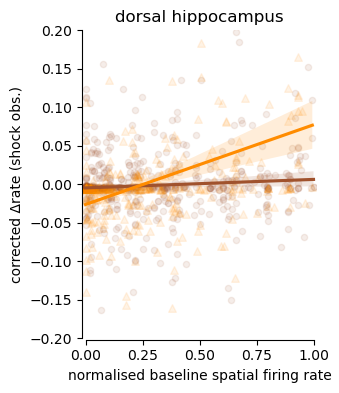

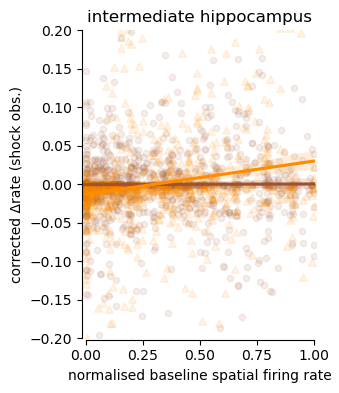

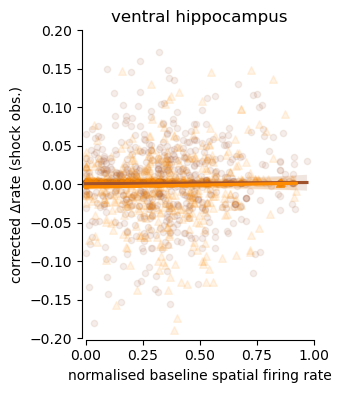

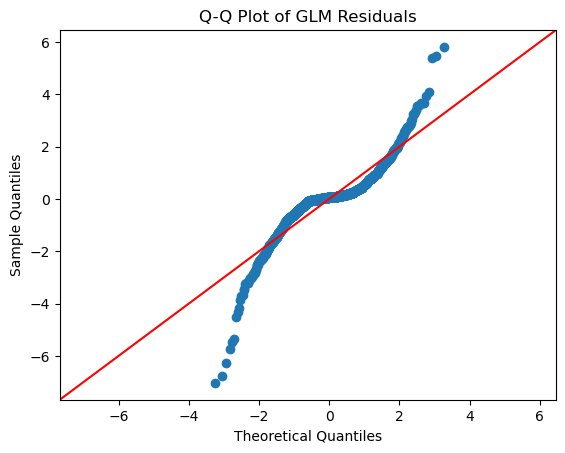

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:15

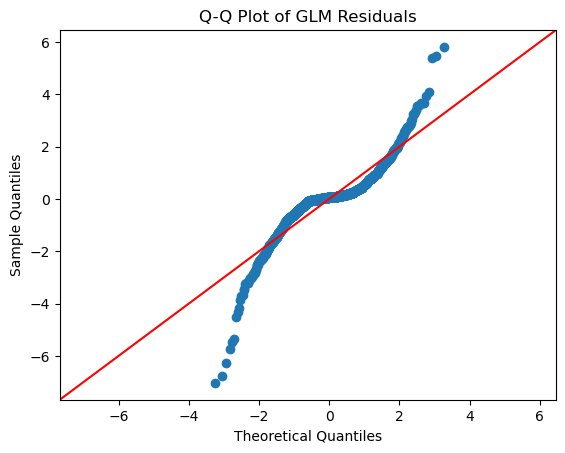

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1533: RuntimeWarning: divide by zero encountered in log
  cov_aug_logdet = cov_re_logdet + np.sum(np.log(vc_var))
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:1537: RuntimeWarning: divide by zero encountered in divide
  solver = _smw_solver(1., ex_r, ex2_r, cov_re_inv, 1 / vc_var)
/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:15

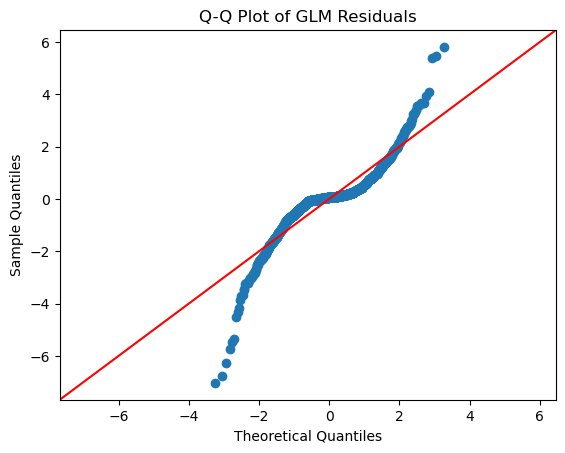


--- dorsal hippocampus ---
                   0        1                    2                3
0             Model:  MixedLM  Dependent Variable:  rate_delta_corr
1  No. Observations:     1778              Method:             REML
2        No. Groups:        1               Scale:           0.0017
3   Min. group size:     1778      Log-Likelihood:        3070.8882
4   Max. group size:     1778           Converged:              Yes
5   Mean group size:   1778.0                                      
                                                                         Coef. Std.Err.       z  P>|z|  [0.025 0.975]
Intercept                                                                0.003    0.165   0.021  0.983  -0.320  0.327
C(stimulus)[T.shock]                                                    -0.012    0.006  -1.853  0.064  -0.024  0.001
context_learning[T.RECALLER]                                            -0.002    0.063  -0.039  0.969  -0.126  0.121
C(stimulus)[T.shock]:con

In [6]:
df = pd.read_parquet('Fig3c.parquet')


for po in ['dorsal', 'intermediate', 'ventral']:
    tmp_model = df.query("pole == '{}'".format(po))

    fig, ax = plt.subplots(1, 1, figsize=(3, 4))

    sns.regplot(x='base_place_rate_post', y='rate_delta_corr',
                data=tmp_model.query("stimulus == 'noshock'"),
                ci=95, marker='.', scatter_kws={'alpha': 0.1, 's': 80},
                color='sienna', label='control moments', ax=ax)
    sns.regplot(x='base_place_rate_post', y='rate_delta_corr',
                data=tmp_model.query("stimulus == 'shock'"),
                ci=95, marker='^', scatter_kws={'alpha': 0.1, 's': 30},
                color='darkorange', label='shock observation', ax=ax)

    ax.set(xlim=(-0.01, 1.01), ylim=(-0.2, 0.2),
           xlabel='normalised baseline spatial firing rate',
           ylabel=u'corrected Δrate (shock obs.)',
           title='{} hippocampus'.format(po))
    sns.despine(offset=True, trim=True)

stats = []

for pole in ['dorsal', 'intermediate', 'ventral']:
    tmp_model = df.query("pole == '{}'".format(po))
    tmp_model = tmp_model.replace({'not learned': 'NON-RECALLER', 'learned': 'RECALLER'})
    tmp_model['response'] = ['ShockObs+' if r == 'excited' else 'rest'
                              for r in tmp_model.shocks_response]
    tmp_model['response'] = (tmp_model['response']
                              .astype('category')
                              .cat.reorder_categories(['rest', 'ShockObs+']))

    fixed_formula = "rate_delta_corr ~ base_place_rate_post * C(stimulus) * context_learning"
    vc_formula    = {'rat': 'C(rat)'}
    oo = np.ones(tmp_model.shape[0])

    model   = sm.MixedLM.from_formula(fixed_formula, data=tmp_model,
                                       groups=oo, vc_formula=vc_formula)
    results = model.fit()
    summ    = results.summary()

    stats.append("")
    stats.append("--- {} hippocampus ---".format(pole))
    stats.append(summ.tables[0].to_string())
    stats.append(summ.tables[1].to_string())

    # 3. Extract the deviance residuals
    residuals = results.resid
    
    # --- METHOD 1: Visual Inspection (Q-Q Plot) ---
    sm.qqplot(residuals, line='45', fit=True)
    plt.title("Q-Q Plot of GLM Residuals")
    plt.show()

for line in stats:
    print(line)